In [ ]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.2 MB/s eta 0:00:00


In [ ]:
import medmnist
from medmnist import BreastMNIST

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns

In [ ]:
train_dataset = BreastMNIST(split='train', download=True)
test_dataset = BreastMNIST(split='test', download=True)

print("Train Samples:", len(train_dataset))
print("Test Samples:", len(test_dataset))

Train Samples: 546
Test Samples: 156


In [ ]:
X_train = train_dataset.imgs
y_train = train_dataset.labels

X_test = test_dataset.imgs
y_test = test_dataset.labels

print(X_train.shape)
print(X_test.shape)

(546, 28, 28)
(156, 28, 28)


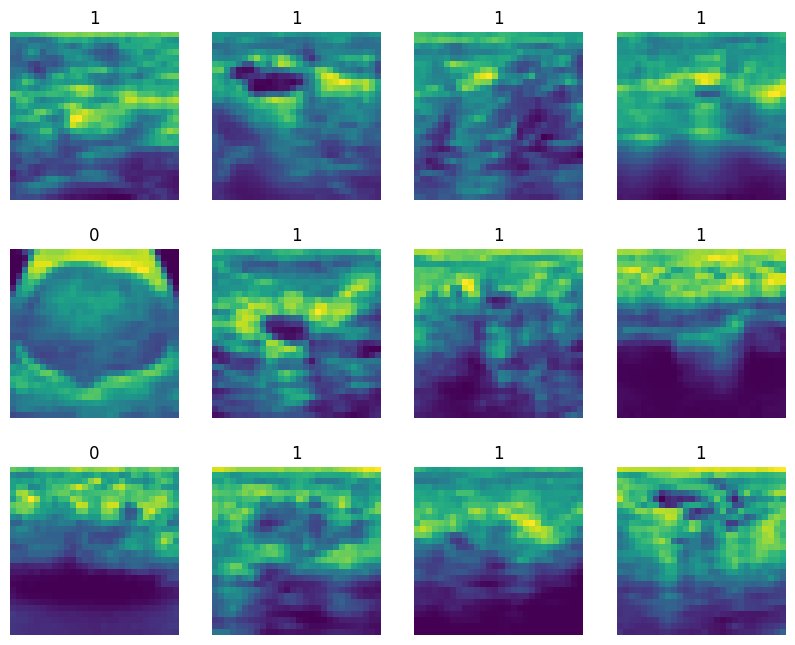

In [ ]:
plt.figure(figsize=(10,8))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_train[i])
    plt.title(y_train[i][0])
    plt.axis("off")

plt.show()

In [ ]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

y_train = tf.keras.utils.to_categorical(y_train, 2)
y_test = tf.keras.utils.to_categorical(y_test, 2)

print(X_train.shape)
print(X_test.shape)

(546, 28, 28, 1)
(156, 28, 28, 1)


In [ ]:
from tensorflow.keras import Input

model = Sequential([

    Input(shape=(28,28,1)),

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        2,
        activation='softmax'
    )
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,354 (1.48 MB)

 Trainable params: 388,354 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - accuracy: 0.7106 - loss: 0.5965 - val_accuracy: 0.7308 - val_loss: 0.5660
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7271 - loss: 0.5739 - val_accuracy: 0.7436 - val_loss: 0.5981
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7308 - loss: 0.5743 - val_accuracy: 0.7308 - val_loss: 0.5652
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7344 - loss: 0.5536 - val_accuracy: 0.7756 - val_loss: 0.5373
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7601 - loss: 0.5189 - val_accuracy: 0.7821 - val_loss: 0.4983
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7821 - loss: 0.4955 - val_accuracy: 0.8077 - val_loss: 0.4706
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7894 - loss: 0.4815 - val_accuracy: 0.7756 - val_loss: 0.4686
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7692 - loss: 0.5087 - val_accuracy: 0.7885 - 

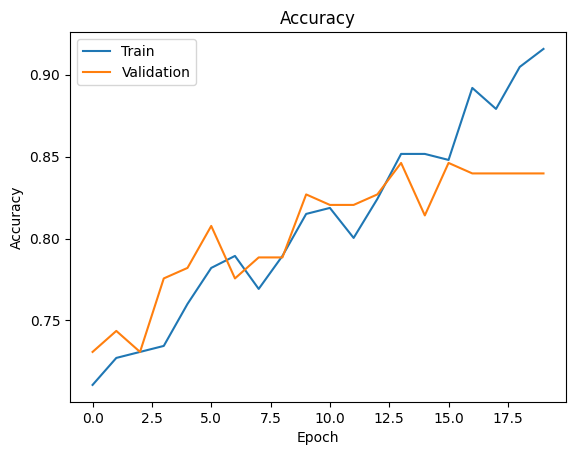

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

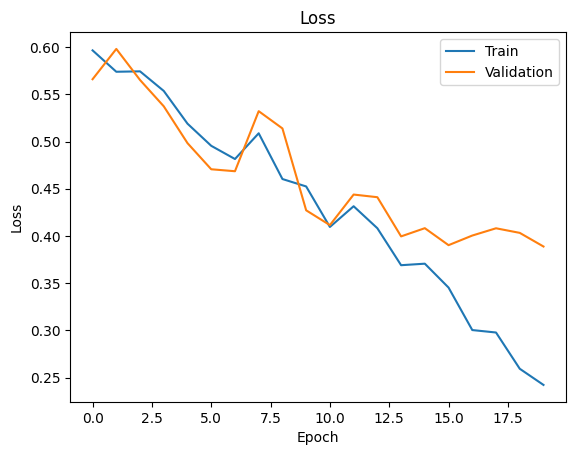

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8397 - loss: 0.3889 
Test Accuracy: 0.8397436141967773


In [ ]:
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step


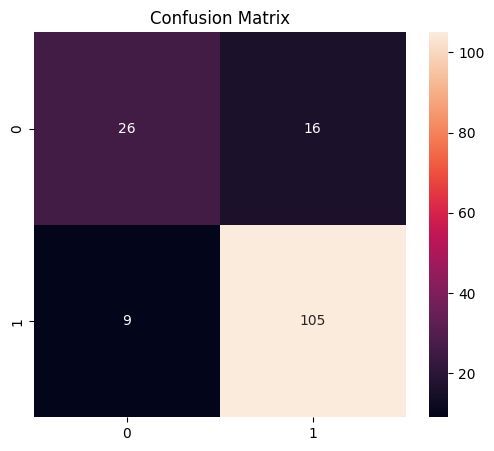

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.74      0.62      0.68        42
           1       0.87      0.92      0.89       114

    accuracy                           0.84       156
   macro avg       0.81      0.77      0.78       156
weighted avg       0.83      0.84      0.83       156



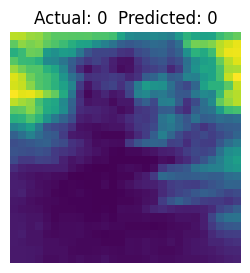

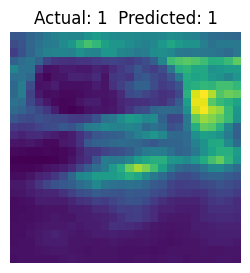

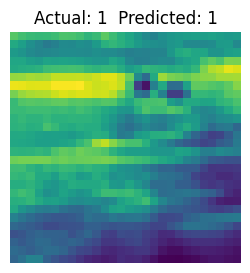

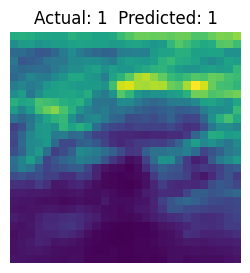

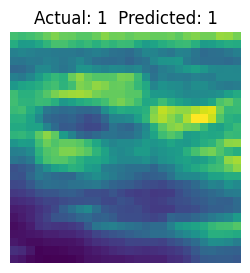

In [ ]:
for i in range(5):

    plt.figure(figsize=(3,3))

    plt.imshow(X_test[i])

    plt.title(
        f"Actual: {y_true[i]}  Predicted: {y_pred[i]}"
    )

    plt.axis('off')

    plt.show()

In [ ]:
model.save("breast_cancer_detection.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
loaded_model = tf.keras.models.load_model(
    "breast_cancer_detection.keras"
)

print("Model Loaded Successfully")

Model Loaded Successfully
